In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.isothermal_flow import (
    NSIsothermalMultiTrajectoryGLSConfig,
    generate_isothermal_ns_dataset,
    run_ns_isothermal_multi_trajectory_gls_experiment,
)
from mfsindy.cases.isothermal_flow_plots import COLORS_MODELS
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]

cfg = NSIsothermalMultiTrajectoryGLSConfig(
    n_runs=5,          # increase if compute budget allows            
    results_dir=str(RESULTS_DIR),
    results_filename="navierstokes_part1_errors.csv",
)


# Navier Stokes Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Isothermal Navier-Stokes equation using the multi-trajectory (Part 1) workflow.

## Governing equations

The isothermal compressible Navier–Stokes equations are

$$
\begin{aligned}
\partial_t \rho + \nabla \cdot (\rho \mathbf{u}) &= 0 \\
\partial_t (\rho \mathbf{u}) + \nabla \cdot (\rho \mathbf{u}\otimes \mathbf{u}) + \nabla p &= \mu \Delta \mathbf{u},
\end{aligned}
$$

where $\rho(\mathbf{x},t)$ is the density, $\mathbf{u}(\mathbf{x},t)$ is the velocity field, $p$ is the pressure, and $\mu$ is the viscosity coefficient. Under the isothermal ideal-gas assumption, the pressure is given by the equation of state

$$
p = \rho R T,
$$

where $R$ is the specific gas constant and $T$ is the constant temperature

We use parameters $(\mu, c_s)$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.

### Trajectory snapshot
Preview noisy LF/HF trajectories and a clean reference.

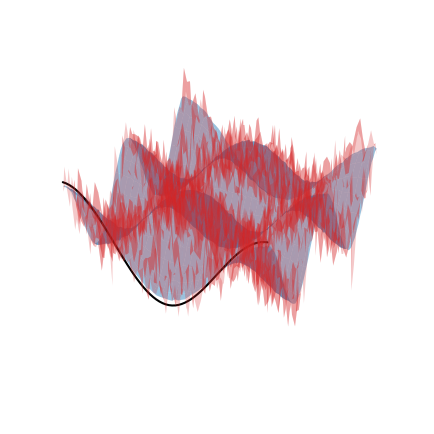

In [ ]:
from mfsindy.cases.isothermal_flow_plots import plot_multifidelity_trajectories
U_ref, _, grid_ref = generate_isothermal_ns_dataset(
    N=cfg.N,
    Nt=cfg.Nt,
    L=cfg.L,
    T=cfg.T,
    mu=cfg.mu,
    RT=cfg.RT,
    seed=cfg.seed_base,
    ic_type="taylor-green",
)
state_std    = float(np.std(U_ref))
noise_hf_abs = cfg.noise_hf_rel * state_std
noise_lf_abs = cfg.noise_lf_rel * state_std

rng_hf = np.random.default_rng(cfg.seed_base + 1000)
rng_lf = np.random.default_rng(cfg.seed_base + 2000)

U_hf_clean, t, grid = generate_isothermal_ns_dataset(
    N=cfg.N,
    Nt=cfg.Nt,
    L=cfg.L,
    T=cfg.T,
    mu=cfg.mu,
    RT=cfg.RT,
    seed=cfg.seed_base,
    ic_type="taylor-green",
)
U_lf_clean, _, _ = generate_isothermal_ns_dataset(
    N=cfg.N,
    Nt=cfg.Nt,
    L=cfg.L,
    T=cfg.T,
    mu=cfg.mu,
    RT=cfg.RT,
    seed=cfg.seed_base,
    ic_type="taylor-green",
)

U_hf_noisy = U_hf_clean + noise_hf_abs * rng_hf.standard_normal(U_hf_clean.shape)
U_lf_noisy = U_lf_clean + noise_lf_abs * rng_lf.standard_normal(U_lf_clean.shape)

plot_multifidelity_trajectories(grid_ref, U_hf_noisy, U_lf_noisy, U_ref)


### Run

In [ ]:
(
    _df_errors,
    _mae_errors,
    _l0_errors,
    state_std,
    noise_hf_abs,
    noise_lf_abs,
) = run_ns_isothermal_multi_trajectory_gls_experiment(cfg)

errors_path = Path(cfg.results_dir) / cfg.results_filename
df_errors = pd.read_csv(errors_path)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)

print("Mean Absolute Error")
print(mae_summary)
print("Support Fraction Error")
print(l0_summary)


MC isothermal NS MF:  40%|████      | 2/5 [10:28<15:20, 306.98s/it]

### Error summaries
Bubble histograms summarise the MAE and $L_0$ distributions across methods.

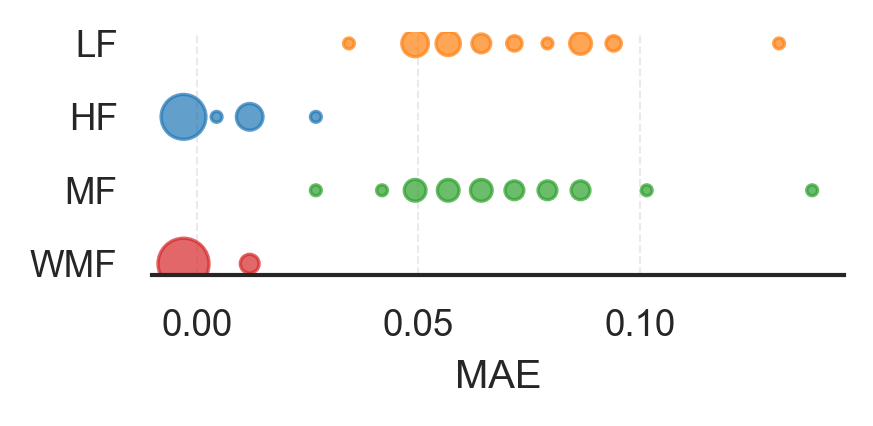

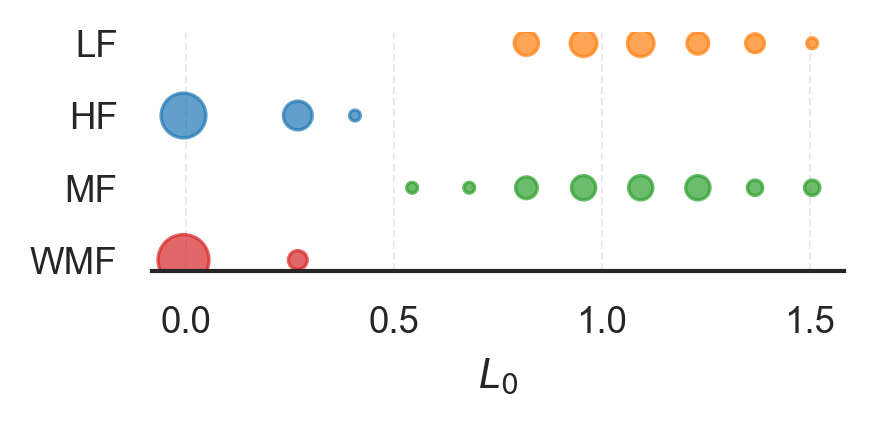

In [ ]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

